In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
from tqdm import tqdm, trange

sys.path.append("../../")
import biked_commons
from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.data_loading import data_loading
from biked_commons.conditioning import conditioning
from biked_commons.design_evaluation.scoring import *
from biked_commons.design_evaluation.score_report import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

c:\Users\Lyler\miniforge3\envs\bike-bench-cuda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup
We first load up the main Bike-Bench predictive modeling dataset.

In [2]:
data = data_loading.load_bike_bench_train()
data_tens = torch.tensor(data.values, dtype=torch.float32, device=device)


 We will use Bike-Bench's standard set of evaluations, provided by ```get_standard_evaluations()```, however for specific purposes you may handpick evaluation functions. 

In [3]:
evaluations_list = get_standard_evaluations(device, aesthetics_mode="Embedding")
print(evaluations_list)

# The evaluation function list can alternatively be customized
# evauations_list = [UsabilityEvaluator(device=device), AeroEvaluator(device=device)]

[<biked_commons.design_evaluation.design_evaluation.UsabilityEvaluator object at 0x000002794C980A00>, <biked_commons.design_evaluation.design_evaluation.AeroEvaluator object at 0x000002794C9827D0>, <biked_commons.design_evaluation.design_evaluation.ErgonomicsEvaluator object at 0x000002794C982920>, <biked_commons.design_evaluation.design_evaluation.AestheticsEvaluator object at 0x000002794C983CD0>, <biked_commons.design_evaluation.design_evaluation.StructuralEvaluator object at 0x000002794C982C20>, <biked_commons.design_evaluation.design_evaluation.ValidationEvaluator object at 0x0000027914149030>, <biked_commons.design_evaluation.design_evaluation.FrameValidityEvaluator object at 0x0000027914149510>]


We initialize the evaluator. We use the ```construct_tensor_evaluator()``` which is gradient-enabled. We also have to pass in the column names so that the evaluator knows which column is which (evaluation functions look for specific columns from the bike-bench data). A dataframe version exists called ```construct_dataframe_evaluator()```, but does not preserve gradients. In either case, we pass in the list of evaluation functions and the function builds a evaluator callable, as well as a set of requirement names (list of strings) and types (list - 1 = objective; 0=constraint). 

In [4]:
evaluator, requirement_names, requirement_types = construct_tensor_evaluator(evaluations_list, data.columns)
print(evaluator)
print(requirement_names)
print(requirement_types)

<function construct_tensor_evaluator.<locals>.evaluate_tensor at 0x000002791D1B8E50>
['Usability Score', 'Drag Force (N)', 'Knee Angle Error (deg.)', 'Hip Angle Error (deg.)', 'Arm Angle Error (deg.)', 'Cosine Distance to Embedding', 'Mass (kg)', 'Planar Compliance Score', 'Transverse Compliance Score', 'Eccentric Compliance Score', 'Planar Safety Factor', 'Eccentric Safety Factor', 'Saddle height too small', 'Seat post too short', 'Head tube lower extension longer than head tube', 'Head tube upper extension and lower extension overlap', 'Strictly postive parameter is negative', 'Chain stay smaller than rear wheel radius', 'Chain stay shorter than BB drop', 'Seat stay smaller than rear wheel radius', 'Seat Tube Intersects Rear Wheel2', "Down tube can't reach head tube", 'Rear wheel cutout severs seat tube', 'Foot intersects front wheel', 'Crank hits ground in lowest position', 'RGB value greater than 255', 'Chain stays intersect', 'Tube wall thickness exceeds radius', 'Down tube inters

Bike-Bench's evaluation functions are designed to be used with a set of conditions. We have provided simple interfaces to sample randomized conditions. Different evaluation functions require different conditioning. Thus you may be able to leave some conditioning information blank. However, for the full set of evaluations, rider geometry, use case and one of three aesthetics conditions (embedding, text, image) are required. Conditional information's outer dimension (batch size) must match the data to evaluate's batch size. As an exception, a condition batch size of 1 is permissable, in which case it is applied to the entire batch of data evaluated, as shown below.  

In [5]:
num_condition = 1
rider_condition = conditioning.sample_riders(num_condition, split="test")
use_case_condition = conditioning.sample_use_case(num_condition, split="test")

image_embeddings = conditioning.sample_image_embedding(num_condition, split="test")
condition = {"Rider": rider_condition, "Use Case": use_case_condition, "Embedding": image_embeddings}

# Example Alternative: sample or create a text condition
# text_condition = conditioning.sample_text(num_condition, split="test")
# evaluations_list = get_standard_evaluations(device, aesthetics_mode="Text")
# evaluator, requirement_names, requirement_types = construct_tensor_evaluator(evaluations_list, data.columns)
# text_condition = ["Futuristic black racing bike"]
# condition = {"Rider": rider_condition, "Use Case": use_case_condition, "Text": text_condition}

### Calling Evaluators
Lets try calling the evaluator on the data. We receive an 3600 x 25 (batch size x n_obj+n_const) tensor as a result. 

In [6]:
eval_scores = evaluator(data_tens, condition)
print(eval_scores.shape)

torch.Size([3600, 30])


All objective scores are ideally minimized at 0. Maximum values for objective scores very. Some are theoretically unbounded. 

In [7]:
objective_scores = eval_scores[:, np.array(requirement_types) == 1]
mean_scores = torch.mean(objective_scores, dim=0).detach().cpu().numpy()
min_scores = torch.min(objective_scores, dim=0).values.detach().cpu().numpy()
print(f"Mean Objective Scores: {mean_scores.round(3)}")
print(f"Min Objective Scores: {min_scores.round(3)}")

Mean Objective Scores: [5.4400e-01 2.2716e+01 2.3044e+01 9.0250e+00 1.5554e+01 4.0000e-03
 4.5890e+00 1.5350e+00 1.2370e+00 1.3580e+00]
Min Objective Scores: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Constraints are considered satsfied if the score value is less or equal to 0. Positive constraint values indicate a constraint violation with the magnitude of the score indicating the degree of constraint violation. 

In [8]:
constraint_scores = eval_scores[:, np.array(requirement_types) == 0]
constraint_satisfied = constraint_scores <= 0
mean_csr = torch.mean(constraint_satisfied.to(float), dim=0)
print(f"Constraint satisfaction rates: {mean_csr.detach().cpu().numpy().round(3)}")

Constraint satisfaction rates: [0.042 0.157 0.989 0.972 0.998 0.979 0.993 0.999 1.    0.998 0.952 1.
 0.999 0.8   0.996 1.    0.978 0.807 0.996 0.986]


We can verify that gradient calculations are working as expected:

In [9]:
#calcualte gradient of scores wrt data_tens

data_tens.requires_grad = True
eval_scores = evaluator(data_tens, condition)
score_sum = eval_scores.sum()
score_sum.backward()

#check for infs and nans in gradients
if torch.isinf(data_tens.grad).any() or torch.isnan(data_tens.grad).any():
    print("Gradient contains infs or nans!")
else:
    print("Gradient is valid.")

Gradient is valid.


### Scoring

Next, we construct the scoring functions. Whereas the evaluators evaluate individual design performance, the scoring functions evaluate the aggregrate quality of a set of design solutions. There are two preset scoring configurations. ```MainScores``` returns the standard maximum mean discrepancy (MMD), hypervolume, and constraint satisfaction rate metrics. ```DetailedScores``` gives a detailed scoring breakdown including min and mean objective scores, constraint violation rate, and mean constraint violation magnitude. 

In [10]:
main_scorer = construct_scorer(MainScores, evaluations_list, data.columns, device)
detailed_scorer = construct_scorer(DetailedScores, evaluations_list, data.columns, device)

In [11]:
main_scorer(data_tens.detach(), condition)

Hypervolume                     0.213291
Constraint Satisfaction Rate    0.012500
Maximum Mean Discrepancy        0.000581
dtype: float64

In [12]:
detailed_scorer(data_tens.detach(), condition)

Min Objective Score: Usability Score                                                             0.227356
Min Objective Score: Drag Force (N)                                                             11.492698
Min Objective Score: Knee Angle Error (deg.)                                                     0.000000
Min Objective Score: Hip Angle Error (deg.)                                                      0.000000
Min Objective Score: Arm Angle Error (deg.)                                                      0.000000
Min Objective Score: Cosine Distance to Embedding                                                0.000291
Min Objective Score: Mass (kg)                                                                   2.250693
Min Objective Score: Planar Compliance Score                                                     0.000000
Min Objective Score: Transverse Compliance Score                                                 0.000000
Min Objective Score: Eccentric Compliance Scor

### Model Scorecards
Bike-Bench provides some visualization dashboards for model performance. Lets try them out. Each model scorecard shows the model's performance relative to other models. We first split up portions of the dataset to simulate sample sets taken from different generative models. The scorecard shows ranks and scores in the principal metrics (MMD, hypervolume, CSR) with competing models indicated with gray ticks. It also shows distributions of objective scores with other models' distributions in gray. Objective plots also show mean objective scores for the model in question and other models benchmarked, as well as the rank of the mean objective score for each objective. Finally, the scorecard shows constraint satisfaction rates and ranks. 

In [13]:
splits = np.array_split(data, 5)
design_batches = [
    torch.tensor(split.values, dtype=torch.float32)
    for i, split in enumerate(splits)]

model_names = [f"Data Subset {i+1}" for i in range(len(design_batches))]

dashboard = ScoreReportDashboard(
    design_batches   = design_batches,
    eval_funcs       = evaluations_list,
    model_names      = model_names,
    condition        = condition,
    column_names     = data.columns.tolist(),
    device           = device
)


c:\Users\Lyler\miniforge3\envs\bike-bench-cuda\lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
c:\Users\Lyler\Documents\Repositories\Bike-Bench-Temporary\src\biked_commons\introductory_notebooks\../..\biked_commons\design_evaluation\score_report.py:99: UserWarning: No model_colors provided; using Matplotlib cycle.
  warnings.warn("No model_colors provided; using Matplotlib cycle.")


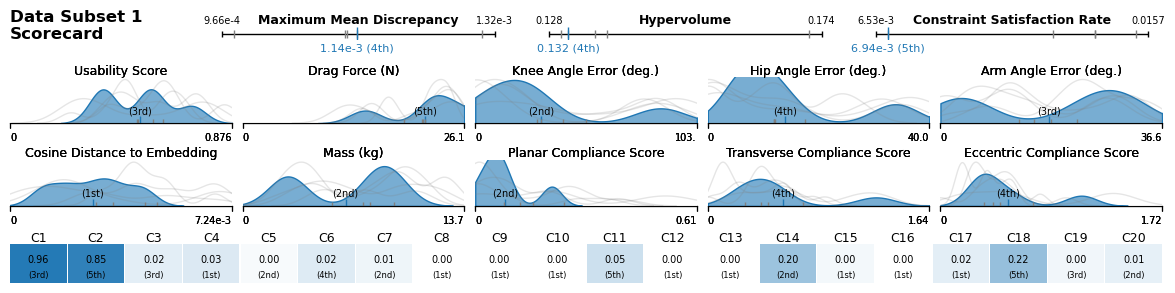

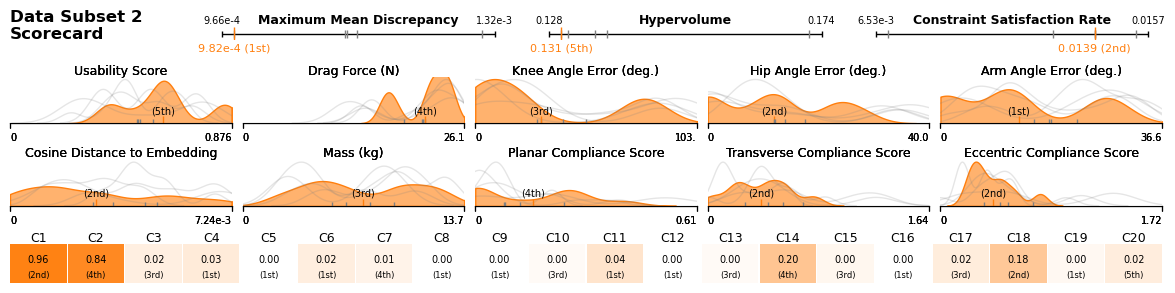

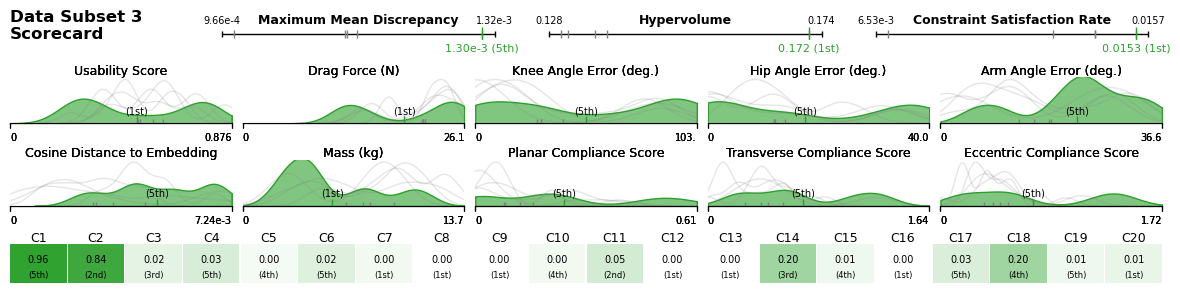

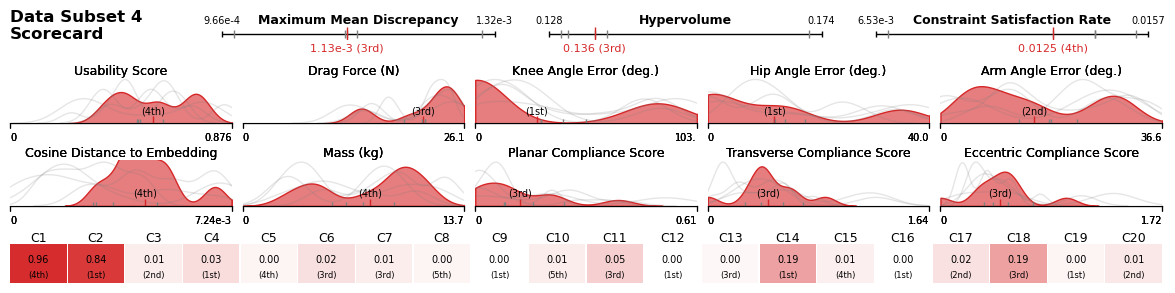

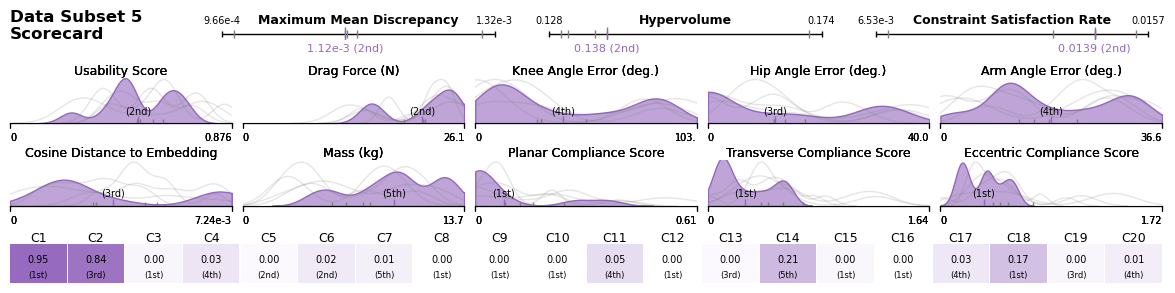

In [14]:
for model in model_names:
    dashboard.show_model(model,)